# SAP MDG Sipariş Yönetiminde Yapay Zeka Destekli Kampanya Önerisi ve Satış Tahmini

Bu çalışma, Online Retail II veri seti kullanılarak müşteri segmentasyonu, kampanya önerisi ve satış tahmini yöntemlerinin SAP MDG tabanlı bir sipariş/müşteri yönetimi senaryosunda nasıl uygulanabileceğini göstermeyi amaçlamaktadır. Çalışma doğrudan bir SAP MDG sistem entegrasyonu içermemektedir.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/online_retail_II.csv")

print(f"Toplam Satır: {len(df):,} | Sütun Sayısı: {df.shape[1]}")
print(f"Sütun Listesi: {df.columns.tolist()}")
df.head()

Toplam Satır: 1,067,371 | Sütun Sayısı: 8
Sütun Listesi: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
# Eksik gözlemlerin dağılımı
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [ ]:
# Sipariş iptalleri ve veri tutarsızlıklarının tespiti ('C' kodlu faturalar ve negatif değerler)
cancelled_count = df['Invoice'].astype(str).str.startswith('C').sum()
invalid_quantities = (df['Quantity'] <= 0).sum()
invalid_prices = (df['Price'] <= 0).sum()

print(f"İptal Edilen Fatura Sayısı: {cancelled_count:,}")
print(f"Negatif/Sıfır Miktar Sayısı: {invalid_quantities:,}")
print(f"Negatif/Sıfır Fiyat Sayısı: {invalid_prices:,}")
print(f"Minimum Değerler -> Miktar: {df['Quantity'].min()} | Fiyat: {df['Price'].min()}")

İptal Edilen Fatura Sayısı: 19,494
Negatif/Sıfır Miktar Sayısı: 22,950
Negatif/Sıfır Fiyat Sayısı: 6,207
Minimum Değerler -> Miktar: -80995 | Fiyat: -53594.36


In [ ]:
# İptal edilen siparişler, hatalı/negatif kayıtlar ve tanımsız ürünlerin filtrelenmesi
df_clean = df[
    (~df['Invoice'].astype(str).str.startswith('C')) &
    (df['Quantity'] > 0) &
    (df['Price'] > 0) &
    (df['Description'].notnull())
].copy()

print(f"Temizlik öncesi: {len(df):,} satır")
print(f"Temizlik sonrası: {len(df_clean):,} satır")

Temizlik öncesi: 1,067,371 satır
Temizlik sonrası: 1,041,670 satır


In [ ]:
tekrar_sayisi = df_clean.duplicated().sum()
print(f"Temizlenmiş veri içerisindeki tekrarlanan satır sayısı: {tekrar_sayisi:,}")

Temizlenmiş veri içerisindeki tekrarlanan satır sayısı: 33,757


In [ ]:
df[df.duplicated(keep=False)].sort_values(['Invoice', 'StockCode']).head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom


In [ ]:
# Aynı fatura, ürün ve zaman damgasına sahip tekrar kayıtların kaldırılması
df_clean = df_clean.drop_duplicates().copy()
print(f"Duplicate temizliği sonrası satır sayısı: {len(df_clean):,}")

Duplicate temizliği sonrası satır sayısı: 1,007,913


In [ ]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [ ]:
# Muhasebe, kargo ve servis kayıtlarının (gerçek ürün olmayan kalemler) filtrelenmesi
non_product_codes = ['POST', 'DOT', 'M', 'BANK CHARGES', 'AMAZONFEE', 'ADJUST']
df_clean = df_clean[~df_clean['StockCode'].astype(str).str.upper().isin(non_product_codes)]

print(f"Filtreleme sonrası satır sayısı: {len(df_clean):,}")

Filtreleme sonrası satır sayısı: 1,003,723


In [ ]:
# Müşteri bazlı analiz için Customer ID içeren kayıtların ayrıştırılması
df_customer = df_clean[df_clean['Customer ID'].notnull()].copy()
df_customer['Customer ID'] = df_customer['Customer ID'].astype(int)

print(f"Müşteri bazlı satır sayısı: {len(df_customer):,}")
print(f"Benzersiz müşteri sayısı: {df_customer['Customer ID'].nunique():,}")

Müşteri bazlı satır sayısı: 776,862
Benzersiz müşteri sayısı: 5,853


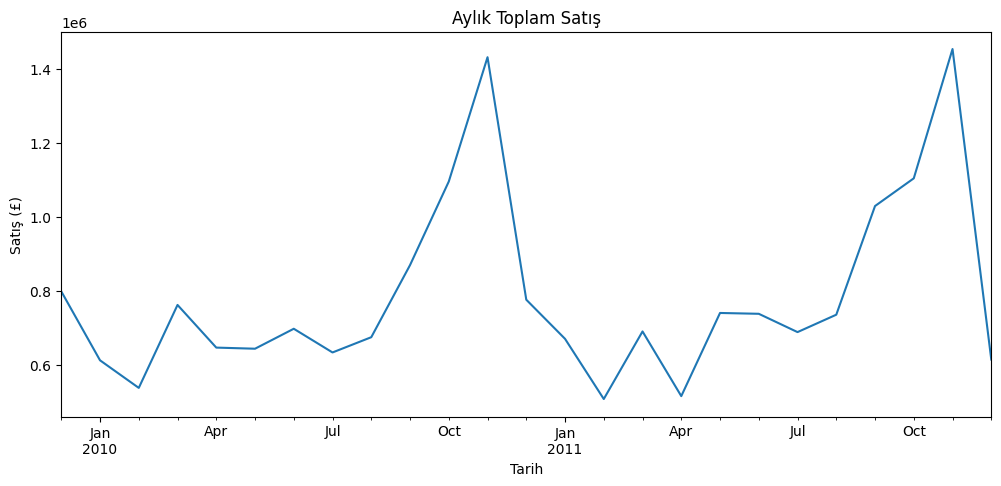

In [ ]:
import matplotlib.pyplot as plt

monthly_sales = df_clean.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot()
plt.title('Aylık Toplam Satış')
plt.xlabel('Tarih')
plt.ylabel('Satış (£)')
plt.show()

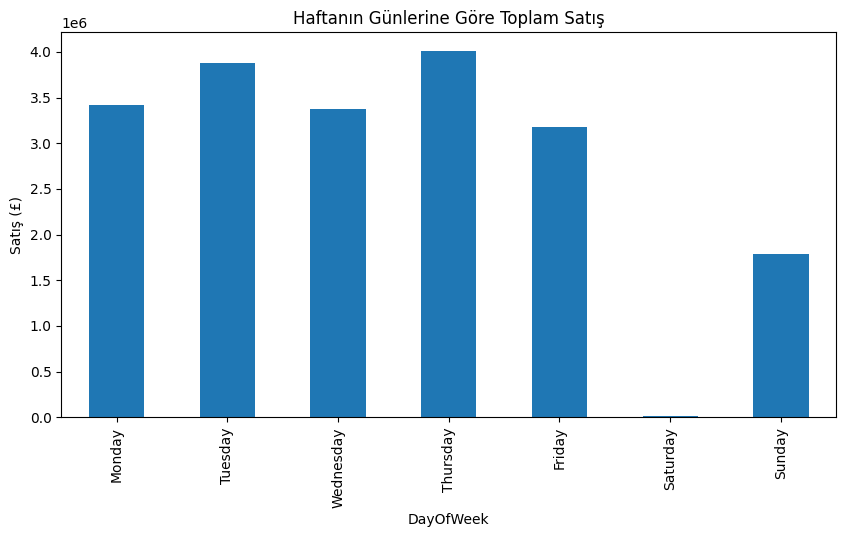

In [ ]:
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()

daily_sales_by_weekday = df_clean.groupby('DayOfWeek')['TotalPrice'].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

plt.figure(figsize=(10, 5))
daily_sales_by_weekday.plot(kind='bar')
plt.title('Haftanın Günlerine Göre Toplam Satış')
plt.ylabel('Satış (£)')
plt.show()

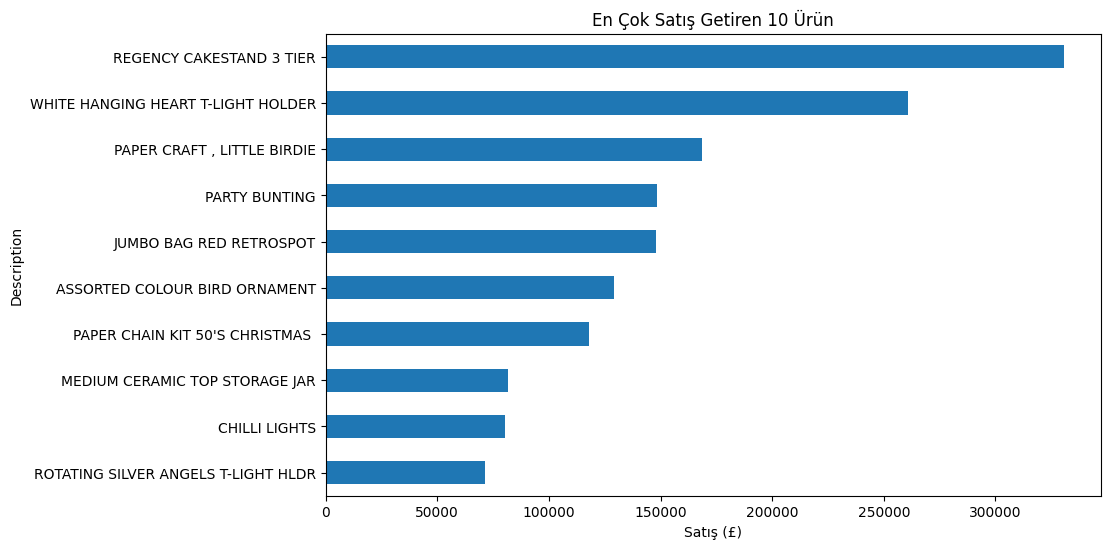

In [ ]:
top_products = df_clean.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products.plot(kind='barh')
plt.title('En Çok Satış Getiren 10 Ürün')
plt.xlabel('Satış (£)')
plt.gca().invert_yaxis()
plt.show()

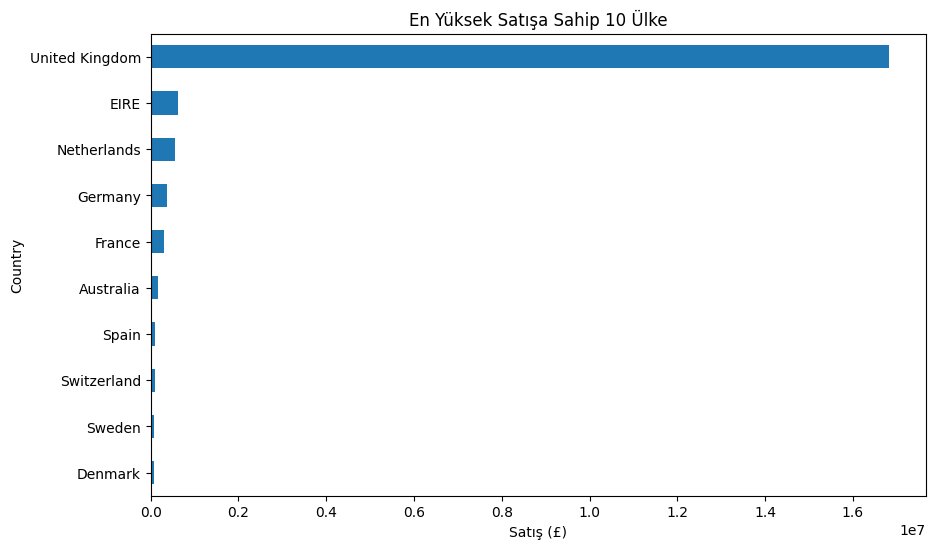

In [ ]:
top_countries = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_countries.plot(kind='barh')
plt.title('En Yüksek Satışa Sahip 10 Ülke')
plt.xlabel('Satış (£)')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
uk_orani = (
    df_clean.loc[df_clean['Country'] == 'United Kingdom', 'TotalPrice'].sum()
    / df_clean['TotalPrice'].sum()
) * 100

print(f"İngiltere'nin toplam satış içindeki payı: %{uk_orani:.2f}")

İngiltere'nin toplam satış içindeki payı: %85.49


## EDA Bulguları

- Satışlarda güçlü bir mevsimsellik var; Kasım aylarında Noel öncesi dönemde belirgin bir artış, Ocak-Şubat'ta ise düşüş gözlemleniyor.
- Cumartesi günlerinde satış hacmi oldukça düşük olup satışların büyük ölçüde hafta içi günlerde yoğunlaştığı görülmektedir. Bu yapı B2B ağırlıklı bir müşteri profiliyle ilişkili olabilir; ancak mevcut veri tek başına bunu kesin olarak doğrulamamaktadır.
- En çok satış getiren ürünler arasında REGENCY CAKESTAND 3 TIER ve WHITE HANGING HEART T-LIGHT HOLDER öne çıkıyor.
- Satışların büyük çoğunluğu (%85.49) İngiltere'den geliyor, diğer ülkelerin payı sınırlı.

## RFM Müşteri Segmentasyonu

In [ ]:
son_tarih = df_customer['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_customer.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (son_tarih - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,1658.40
3,12349,19,3,3678.69
4,12350,310,1,294.40


In [ ]:
ek_ozellikler = df_customer.groupby('Customer ID').agg(
    Ulke=('Country', lambda x: x.mode()[0]),
    Ort_Sepet_Buyuklugu=('Quantity', 'mean'),
    Ort_Urun_Fiyati=('Price', 'mean')
).reset_index()

rfm = rfm.merge(ek_ozellikler, on='Customer ID', how='left')
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Ulke,Ort_Sepet_Buyuklugu,Ort_Urun_Fiyati
0,12346,326,12,77556.46,United Kingdom,2184.852941,6.100000
1,12347,2,8,4921.53,Iceland,13.364865,2.498063
2,12348,75,5,1658.40,Finland,58.782609,0.697826
3,12349,19,3,3678.69,Italy,9.424419,4.246744
4,12350,310,1,294.40,Norway,12.250000,1.581250


In [ ]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Ulke,Ort_Sepet_Buyuklugu,Ort_Urun_Fiyati,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,12,77556.46,United Kingdom,2184.852941,6.100000,2,5,5,255
1,12347,2,8,4921.53,Iceland,13.364865,2.498063,5,4,5,545
2,12348,75,5,1658.40,Finland,58.782609,0.697826,3,4,4,344
3,12349,19,3,3678.69,Italy,9.424419,4.246744,5,3,5,535
4,12350,310,1,294.40,Norway,12.250000,1.581250,2,1,2,212


In [ ]:
def segment_belirle(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if r >= 4 and f >= 4:
        return 'Sadık Müşteri'
    elif r >= 4 and f <= 2:
        return 'Yeni / Potansiyel Müşteri'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Kaybedilme Riski (Değerli)'
    elif r <= 2 and f <= 2:
        return 'Pasif/Kaybedilmiş'
    else:
        return 'Orta Segment'

rfm['Segment'] = rfm.apply(segment_belirle, axis=1)
rfm['Segment'].value_counts()

,count
Segment,
Orta Segment,2189
Pasif/Kaybedilmiş,1509
Sadık Müşteri,1475
Yeni / Potansiyel Müşteri,451
Kaybedilme Riski (Değerli),229


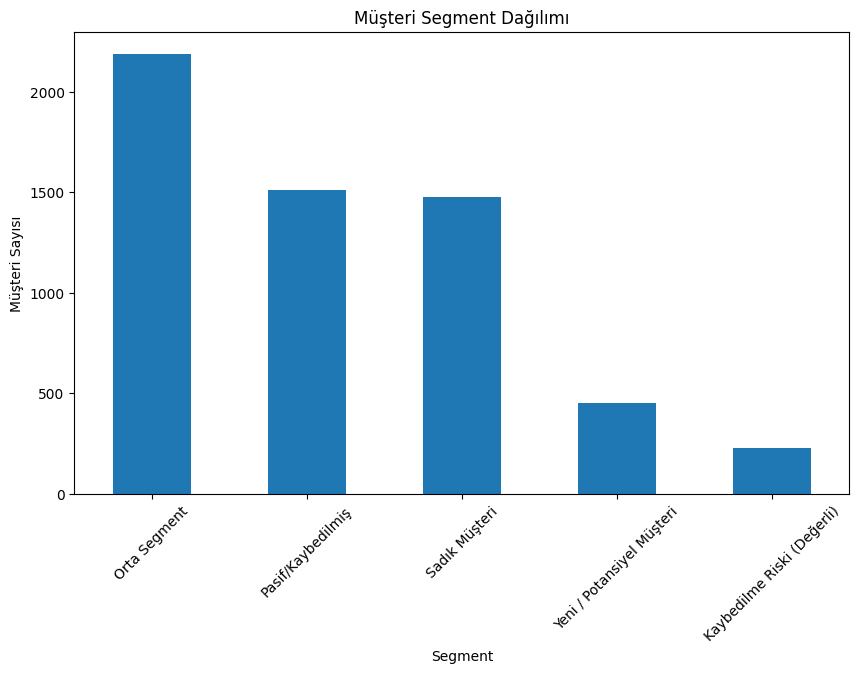

In [ ]:
plt.figure(figsize=(10, 6))
rfm['Segment'].value_counts().plot(kind='bar')
plt.title('Müşteri Segment Dağılımı')
plt.ylabel('Müşteri Sayısı')
plt.xticks(rotation=45)
plt.show()

Müşteri kitlesinin büyük kısmı Orta Segment ve Pasif/Kaybedilmiş gruplarında toplanıyor. Sadık Müşteri segmenti de önemli bir paya sahip. Kaybedilme Riski (Değerli) segmenti, Recency ve Frequency'nin yanı sıra Monetary eşiği de sağlandığında atandığı için sayıca sınırlı (229 müşteri) ama gerçekten yüksek geçmiş harcamaya sahip, öncelikli bir hedef kitleyi temsil ediyor.

Not: Kullanılan segmentler, literatürdeki standart tek bir RFM sınıflandırmasının birebir uygulanması değil, bu çalışmanın kampanya senaryosuna uygun olarak belirlenen kural tabanlı gruplardır.

In [ ]:
segment_ozeti = rfm.groupby('Segment').agg(
    Musteri_Sayisi=('Customer ID', 'count'),
    Ortalama_Recency=('Recency', 'mean'),
    Ortalama_Frequency=('Frequency', 'mean'),
    Ortalama_Monetary=('Monetary', 'mean')
).round(2)

segment_ozeti

,Musteri_Sayisi,Ortalama_Recency,Ortalama_Frequency,Ortalama_Monetary
Segment,,,,
Kaybedilme Riski (Değerli),229,342.41,9.06,4387.84
Orta Segment,2189,165.09,4.13,1468.88
Pasif/Kaybedilmiş,1509,456.95,1.25,411.50
Sadık Müşteri,1475,20.37,15.56,8016.80
Yeni / Potansiyel Müşteri,451,28.13,1.46,923.65


## Segment Bazlı Kampanya Önerisi

In [ ]:
kampanya_haritasi = {
    'Sadık Müşteri': 'Sadakat Programı / Erken Erişim',
    'Kaybedilme Riski (Değerli)': 'Yüksek İndirim / Kişisel Teklif',
    'Pasif/Kaybedilmiş': 'Geri Kazanma Kampanyası',
    'Yeni / Potansiyel Müşteri': 'Hoş Geldin Kampanyası',
    'Orta Segment': 'Çapraz Satış Önerisi'
}

rfm['Onerilen_Kampanya'] = rfm['Segment'].map(kampanya_haritasi)
rfm[['Customer ID', 'Segment', 'Onerilen_Kampanya']].head(10)

,Customer ID,Segment,Onerilen_Kampanya
0,12346,Kaybedilme Riski (Değerli),Yüksek İndirim / Kişisel Teklif
1,12347,Sadık Müşteri,Sadakat Programı / Erken Erişim
2,12348,Orta Segment,Çapraz Satış Önerisi
3,12349,Orta Segment,Çapraz Satış Önerisi
4,12350,Pasif/Kaybedilmiş,Geri Kazanma Kampanyası
5,12351,Pasif/Kaybedilmiş,Geri Kazanma Kampanyası
6,12352,Sadık Müşteri,Sadakat Programı / Erken Erişim
7,12353,Pasif/Kaybedilmiş,Geri Kazanma Kampanyası
8,12354,Pasif/Kaybedilmiş,Geri Kazanma Kampanyası
9,12355,Pasif/Kaybedilmiş,Geri Kazanma Kampanyası


## Makine Öğrenmesi ile Kampanya Sınıflandırma Modeli

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

rfm_model = pd.get_dummies(rfm, columns=['Ulke'], prefix='Ulke')

ozellik_sutunlari = ['Recency', 'Frequency', 'Monetary', 'Ort_Sepet_Buyuklugu', 'Ort_Urun_Fiyati'] + \
    [col for col in rfm_model.columns if col.startswith('Ulke_')]

X = rfm_model[ozellik_sutunlari]
y = rfm['Onerilen_Kampanya']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Eğitim seti: {X_train.shape[0]} örnek")
print(f"Test seti: {X_test.shape[0]} örnek")
print(f"Toplam özellik sayısı: {X_train.shape[1]}")

Eğitim seti: 4682 örnek
Test seti: 1171 örnek
Toplam özellik sayısı: 46


In [ ]:
# Random Forest sınıflandırıcı ile model eğitimi ve test seti üzerinde performans değerlendirmesi
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Doğruluk (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\n", classification_report(y_test, y_pred, target_names=le.classes_))

Doğruluk (Accuracy): 0.9342

                                  precision    recall  f1-score   support

        Geri Kazanma Kampanyası       0.92      0.97      0.94       302
          Hoş Geldin Kampanyası       0.88      0.92      0.90        90
Sadakat Programı / Erken Erişim       0.99      0.95      0.97       295
Yüksek İndirim / Kişisel Teklif       1.00      0.85      0.92        46
           Çapraz Satış Önerisi       0.91      0.91      0.91       438

                       accuracy                           0.93      1171
                      macro avg       0.94      0.92      0.93      1171
                   weighted avg       0.94      0.93      0.93      1171



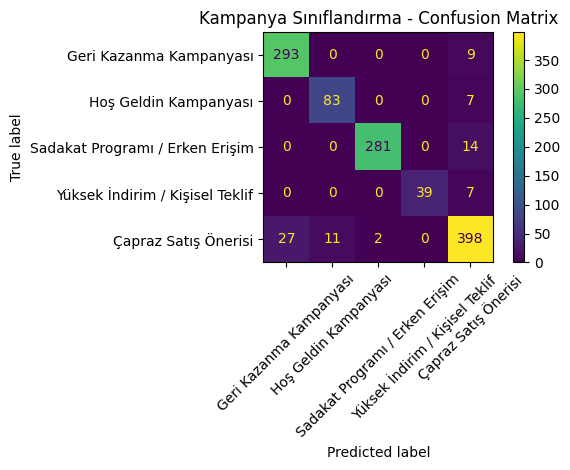

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=le.classes_,
    xticks_rotation=45
)
plt.title('Kampanya Sınıflandırma - Confusion Matrix')
plt.tight_layout()
plt.show()

Model %93.42 doğruluk göstermektedir. Sınıf bazlı performansa bakıldığında, "Sadakat Programı / Erken Erişim" ve "Geri Kazanma Kampanyası" en yüksek doğrulukla ayırt edilen sınıflardır; en fazla karışıklık ise "Çapraz Satış Önerisi" ile diğer sınıflar arasında görülmektedir (bkz. confusion matrix).

Bu performans, modele RFM hesaplamasında kullanılmayan üç yeni özellik (Ulke, Ort_Sepet_Buyuklugu, Ort_Urun_Fiyati) eklenerek elde edilmiştir. Ancak yüksek doğruluk beklenen bir sonuçtur; çünkü kampanya etiketleri hâlâ doğrudan Recency, Frequency ve Monetary değerlerinden türetilmekte ve bu üç değişken modelin girdisinde kalmaya devam etmektedir.

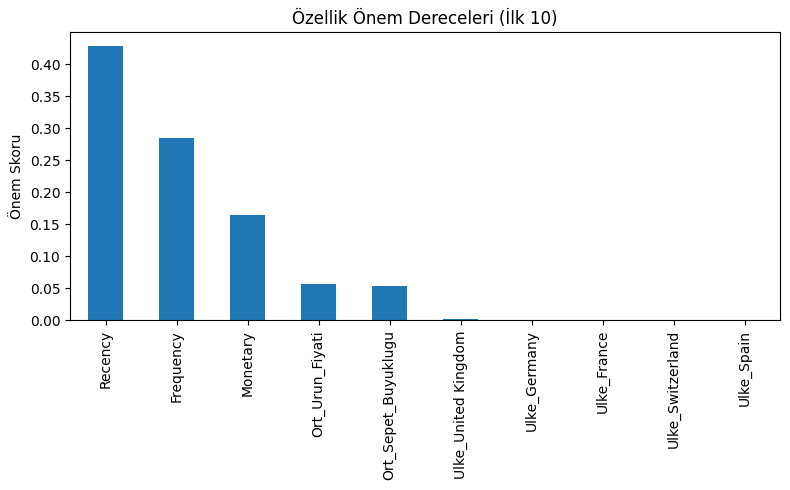

In [ ]:
importances = pd.Series(model.feature_importances_, index=ozellik_sutunlari).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(10).plot(kind='bar')
plt.title('Özellik Önem Dereceleri (İlk 10)')
plt.ylabel('Önem Skoru')
plt.tight_layout()
plt.show()

Random Forest modelinde en yüksek özellik önem skoruna Recency sahip olup, bunu Frequency ve Monetary izlemektedir; bu üç değişken toplamda modelin kararının büyük çoğunluğunu oluşturmaktadır. Ort_Urun_Fiyati ve Ort_Sepet_Buyuklugu değişkenleri sınırlı da olsa katkı sağlarken, ülke bazlı özelliklerin önemi ihmal edilebilir düzeydedir; bu durum, kampanya kuralının ülke bilgisini hiç kullanmamasıyla tutarlıdır. Monetary, ayrıca "Kaybedilme Riski (Değerli)" segmentinin tanımlanmasında doğrudan eşik koşulu olarak da kullanılmıştır.

## Satış Tahmini Modülü

In [ ]:
# Günlük toplam satış zaman serisinin türetilmesi
daily_sales = df_clean.set_index('InvoiceDate').resample('D')['TotalPrice'].sum().reset_index()
daily_sales.columns = ['Tarih', 'Satis']

daily_sales.head()

,Tarih,Satis
0,2009-12-01,52438.61
1,2009-12-02,61873.10
2,2009-12-03,73109.78
3,2009-12-04,39349.21
4,2009-12-05,9803.05


In [ ]:
# Takvim öznitelikleri, gecikme (lag) ve hareketli ortalama değişkenlerinin türetilmesi
daily_sales['Yil'] = daily_sales['Tarih'].dt.year
daily_sales['Ay'] = daily_sales['Tarih'].dt.month
daily_sales['Gun'] = daily_sales['Tarih'].dt.day
daily_sales['HaftaninGunu'] = daily_sales['Tarih'].dt.dayofweek

daily_sales['Lag_1'] = daily_sales['Satis'].shift(1)
daily_sales['Lag_7'] = daily_sales['Satis'].shift(7)
daily_sales['HareketliOrt_7'] = daily_sales['Satis'].shift(1).rolling(window=7).mean()

daily_sales.dropna(inplace=True)
daily_sales.head()

,Tarih,Satis,Yil,Ay,Gun,HaftaninGunu,Lag_1,Lag_7,HareketliOrt_7
7,2009-12-08,48744.71,2009,12,8,1,43057.47,52438.61,43416.605714
8,2009-12-09,38870.31,2009,12,9,2,48744.71,61873.10,42888.905714
9,2009-12-10,42210.37,2009,12,10,3,38870.31,73109.78,39602.792857
10,2009-12-11,39447.89,2009,12,11,4,42210.37,39349.21,35188.591429
11,2009-12-12,0.00,2009,12,12,5,39447.89,9803.05,35202.688571


In [ ]:
ozellikler = ['Yil', 'Ay', 'Gun', 'HaftaninGunu', 'Lag_1', 'Lag_7', 'HareketliOrt_7']
X = daily_sales[ozellikler]
y = daily_sales['Satis']

egitim_boyutu = int(len(daily_sales) * 0.85)
X_train, X_test = X[:egitim_boyutu], X[egitim_boyutu:]
y_train, y_test = y[:egitim_boyutu], y[egitim_boyutu:]

print(f"Eğitim: {len(X_train)} gün, Test: {len(X_test)} gün")

Eğitim: 622 gün, Test: 110 gün


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

model_tahmin = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model_tahmin.fit(X_train, y_train)

y_pred = model_tahmin.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 10655.88
RMSE: 19405.95


In [ ]:
# Naive baseline: geçen haftanın aynı gününün satışı kadar tahmin
baseline_pred = X_test['Lag_7']

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"XGBoost MAE: {mae:.2f}")
print(f"İyileşme oranı: %{((baseline_mae - mae) / baseline_mae) * 100:.1f}")

Baseline MAE: 14413.75
Baseline RMSE: 23175.54
XGBoost MAE: 10655.88
İyileşme oranı: %26.1


In [ ]:
ortalama_satis = y_test.mean()
print(f"Test setinde ortalama günlük satış: {ortalama_satis:.2f}")
print(f"MAE'nin ortalamaya oranı: {(mae / ortalama_satis) * 100:.1f}%")

Test setinde ortalama günlük satış: 40139.11
MAE'nin ortalamaya oranı: 26.5%


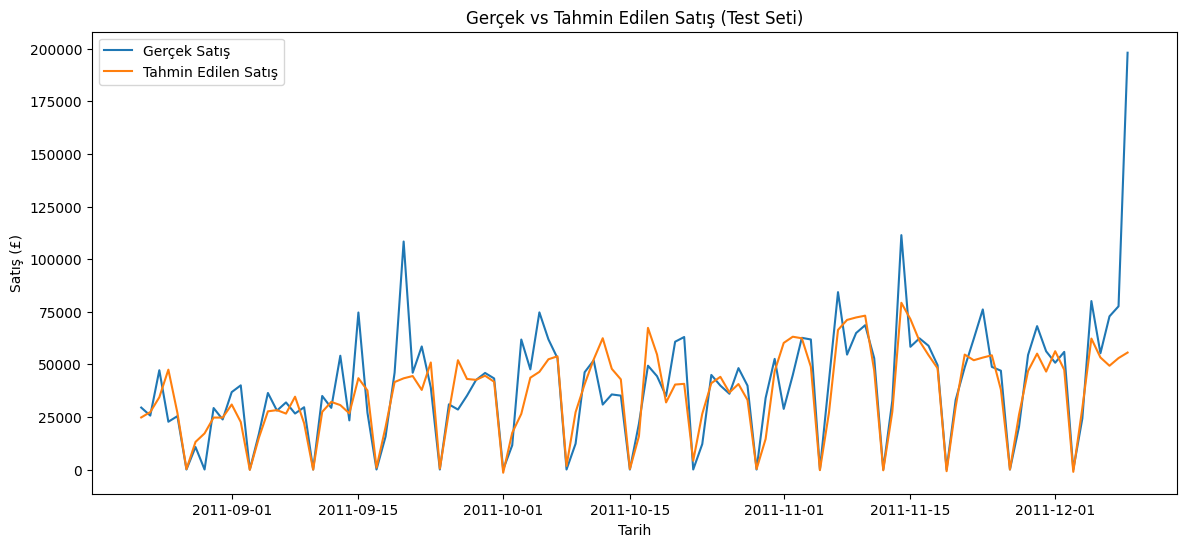

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(daily_sales['Tarih'][egitim_boyutu:], y_test.values, label='Gerçek Satış')
plt.plot(daily_sales['Tarih'][egitim_boyutu:], y_pred, label='Tahmin Edilen Satış')
plt.title('Gerçek vs Tahmin Edilen Satış (Test Seti)')
plt.xlabel('Tarih')
plt.ylabel('Satış (£)')
plt.legend()
plt.show()

Model, haftalık satış döngüsünü (hafta içi/hafta sonu dalgalanmasını) başarılı şekilde yakalamaktadır. MAE'nin ortalama satışa oranı %26.5 olup, bu oranı tek başına değerlendirmek yerine bir referans (baseline) ile karşılaştırmak daha sağlıklıdır. Bu amaçla, "bugünün satışı geçen haftanın aynı günü kadardır" varsayımına dayanan basit bir referans model oluşturulmuştur. XGBoost modeli, bu referansa kıyasla ortalama mutlak hatayı (MAE) %26.1 oranında azaltmıştır. Bu sonuç, modelin basit haftalık tekrar varsayımının ötesinde ek tahmin bilgisi kullanabildiğini göstermektedir. Aralık başındaki olağandışı yüksek satış günü ise model tarafından tam olarak öngörülememiştir; bu durum, geçmişte benzeri görülmemiş uç (outlier) değerlerin tahmin edilmesindeki genel bir zorluğu yansıtmaktadır.

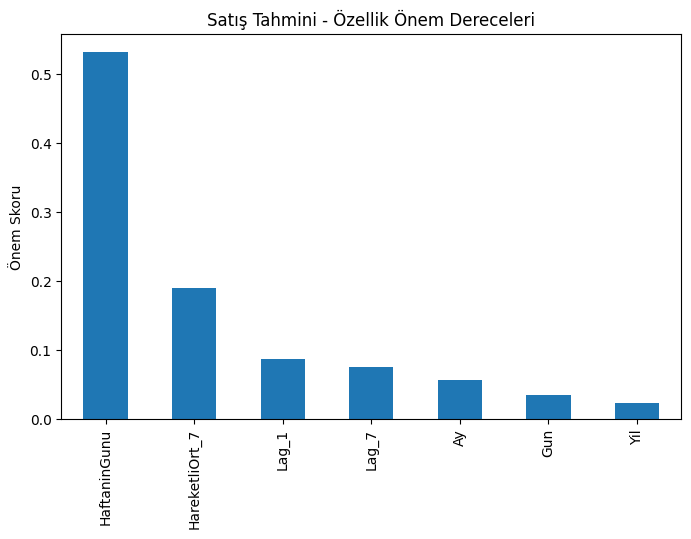

In [ ]:
onem_tahmin = pd.Series(model_tahmin.feature_importances_, index=ozellikler).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
onem_tahmin.plot(kind='bar')
plt.title('Satış Tahmini - Özellik Önem Dereceleri')
plt.ylabel('Önem Skoru')
plt.show()

Random Forest modelinde olduğu gibi burada da HaftaninGunu en yüksek özellik önem skoruna sahiptir; bu durum EDA aşamasında gözlemlenen hafta sonu satış düşüşüyle örtüşmektedir. Hareketli ortalama ve haftalık gecikme (lag) değişkenleri de güçlü katkı sağlarken, Yıl değişkeninin etkisi sınırlı kalmıştır; bu, veri setinin yalnızca iki yıllık bir zaman aralığını kapsamasından kaynaklanmaktadır.

Ayrıca belirtilmelidir ki test değerlendirmesi, önceki günlere ait gerçekleşmiş satış bilgilerinin (Lag_1, Lag_7) kullanılabildiği bir adım ileri (one-step-ahead / rolling) tahmin senaryosunu temsil etmektedir. Bu nedenle sonuçlar, tüm test döneminin baştan tek seferde ve çok adımlı olarak tahmin edildiği bir senaryo olarak değerlendirilmemelidir.

In [ ]:
cumartesi_ornekleri = daily_sales[daily_sales['Tarih'].dt.dayofweek == 5].tail(10)
cumartesi_ornekleri

,Tarih,Satis,Yil,Ay,Gun,HaftaninGunu,Lag_1,Lag_7,HareketliOrt_7
669,2011-10-01,0.0,2011,10,1,5,43287.72,0.0,32328.007286
676,2011-10-08,0.0,2011,10,8,5,52905.37,0.0,44336.657143
683,2011-10-15,0.0,2011,10,15,5,35112.42,0.0,30289.092857
690,2011-10-22,0.0,2011,10,22,5,62978.39,0.0,39159.938571
697,2011-10-29,0.0,2011,10,29,5,39845.95,0.0,31570.145714
704,2011-11-05,0.0,2011,11,5,5,61799.62,0.0,40663.145714
711,2011-11-12,0.0,2011,11,12,5,52913.44,0.0,52491.982857
718,2011-11-19,0.0,2011,11,19,5,49613.18,0.0,53312.370000
725,2011-11-26,0.0,2011,11,26,5,46959.52,0.0,45075.370000
732,2011-12-03,0.0,2011,12,3,5,55917.17,0.0,43673.050000


## Gelecek Dönem Tahmini (Recursive Forecasting)

In [ ]:
gelecek_gun_sayisi = 30
son_veri = daily_sales.copy().reset_index(drop=True)

gelecek_tahminler = []

for i in range(gelecek_gun_sayisi):
    son_tarih = son_veri['Tarih'].iloc[-1]
    yeni_tarih = son_tarih + pd.Timedelta(days=1)

    ozellik_satiri = {
        'Yil': yeni_tarih.year,
        'Ay': yeni_tarih.month,
        'Gun': yeni_tarih.day,
        'HaftaninGunu': yeni_tarih.dayofweek,
        'Lag_1': son_veri['Satis'].iloc[-1],
        'Lag_7': son_veri['Satis'].iloc[-7],
        'HareketliOrt_7': son_veri['Satis'].iloc[-7:].mean()
    }

    X_yeni = pd.DataFrame([ozellik_satiri])[ozellikler]
    tahmin_degeri = max(0, model_tahmin.predict(X_yeni)[0])

    if yeni_tarih.dayofweek == 5:
        tahmin_degeri = 0.0

    gelecek_tahminler.append({'Tarih': yeni_tarih, 'Tahmin': tahmin_degeri})

    yeni_satir = pd.DataFrame([{'Tarih': yeni_tarih, 'Satis': tahmin_degeri}])
    son_veri = pd.concat([son_veri, yeni_satir], ignore_index=True)

gelecek_df = pd.DataFrame(gelecek_tahminler)
gelecek_df['Tahmin'] = gelecek_df['Tahmin'].round(2)
gelecek_df

,Tarih,Tahmin
0,2011-12-10,0.00
1,2011-12-11,23452.47
2,2011-12-12,83886.26
3,2011-12-13,62480.26
4,2011-12-14,54904.32
5,2011-12-15,53507.71
6,2011-12-16,42058.54
7,2011-12-17,0.00
8,2011-12-18,23054.27
9,2011-12-19,59341.85


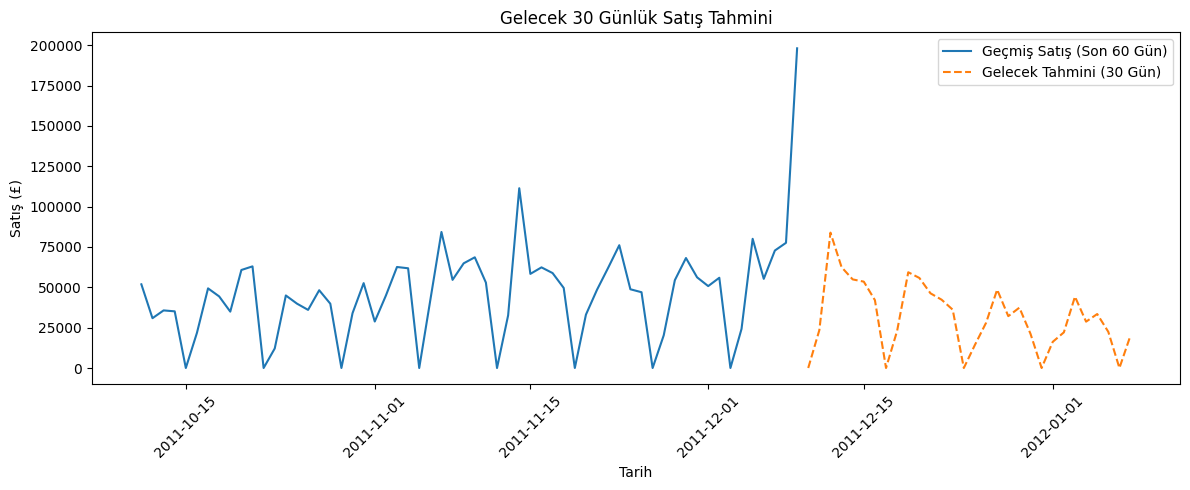

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(daily_sales['Tarih'].tail(60), daily_sales['Satis'].tail(60), label='Geçmiş Satış (Son 60 Gün)')
plt.plot(gelecek_df['Tarih'], gelecek_df['Tahmin'], label='Gelecek Tahmini (30 Gün)', linestyle='--')
plt.title('Gelecek 30 Günlük Satış Tahmini')
plt.xlabel('Tarih')
plt.ylabel('Satış (£)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bu grafik, veri setinin son gününden (2011-12-09) itibaren gelecek 30 gün için üretilen recursive (özyinelemeli) tahminleri göstermektedir. Model, bir önceki günün tahminini bir sonraki günün girdisi olarak kullanarak ilerlemektedir.

Not: Model, ham haliyle bazı hafta sonu (Cumartesi) günlerinde sıfırdan farklı, düşük değerler üretebilmektedir. Ancak geçmiş veride Cumartesi günlerinin satışı istisnasız şekilde sıfır olduğundan, bu iş kuralı modele son bir kural (post-processing) olarak eklenmiştir. Bu durum, modelin saf istatistiksel örüntüyle her zaman %100 kesin iş kurallarını (mağazanın kapalı olduğu günler gibi) öğrenemediğini göstermektedir.

## Sonuçların Dışa Aktarılması

In [ ]:

rfm_kaydet = rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Ulke', 'Ort_Sepet_Buyuklugu', 'Ort_Urun_Fiyati', 'Segment', 'Onerilen_Kampanya']].copy()
rfm_kaydet['Monetary'] = rfm_kaydet['Monetary'].round(2)
rfm_kaydet.to_csv('rfm_kampanya_sonuclari.csv', index=False)

satis_sonuclari = daily_sales.iloc[egitim_boyutu:].copy()
satis_sonuclari['Tahmin'] = y_pred
satis_sonuclari['Satis'] = satis_sonuclari['Satis'].round(2)
satis_sonuclari['Tahmin'] = satis_sonuclari['Tahmin'].round(2)
satis_sonuclari[['Tarih', 'Satis', 'Tahmin']].to_csv('satis_tahmini_sonuclari.csv', index=False)

segment_ozeti_kaydet = segment_ozeti.round(2)
segment_ozeti_kaydet.to_csv('segment_ozeti.csv')

gelecek_df.to_csv('gelecek_tahmin.csv', index=False)

print("Dosyalar kaydedildi.")

Dosyalar kaydedildi.
